<a href="https://colab.research.google.com/github/25ad552-wq/Restaurant_Sales_Analysis/blob/main/ML_Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import all libraries needed
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load the Tips dataset
df = sns.load_dataset('tips')

# Convert text columns to numbers (ML needs numbers only!)
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
df['smoker'] = df['smoker'].map({'Yes': 1, 'No': 0})
df['time'] = df['time'].map({'Dinner': 1, 'Lunch': 0})
df['day'] = df['day'].map({'Sun': 0, 'Sat': 1, 'Fri': 2, 'Thur': 3})

# Show the prepared data
print("Data Shape:", df.shape)
df.head()

Data Shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,0,1,2
1,10.34,1.66,1,0,0,1,3
2,21.01,3.50,1,0,0,1,3
3,23.68,3.31,1,0,0,1,2
4,24.59,3.61,0,0,0,1,4


In [2]:
# Step 1: Define what we're predicting (Y) and what we use to predict (X)
X = df[['total_bill', 'size', 'sex', 'smoker', 'day', 'time']]  # Input features
y = df['tip']  # What we want to predict

# Step 2: Split data - 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape[0], "rows")
print("Testing data size:", X_test.shape[0], "rows")

# Step 3: Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("\n✅ Model trained successfully!")

# Step 4: Test the model
y_pred = model.predict(X_test)

# Step 5: Check accuracy
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Accuracy (R² Score): {r2:.2f}")
print(f"Average Prediction Error: ${mae:.2f}")

Training data size: 195 rows
Testing data size: 49 rows

✅ Model trained successfully!

Model Accuracy (R² Score): 0.44
Average Prediction Error: $0.67


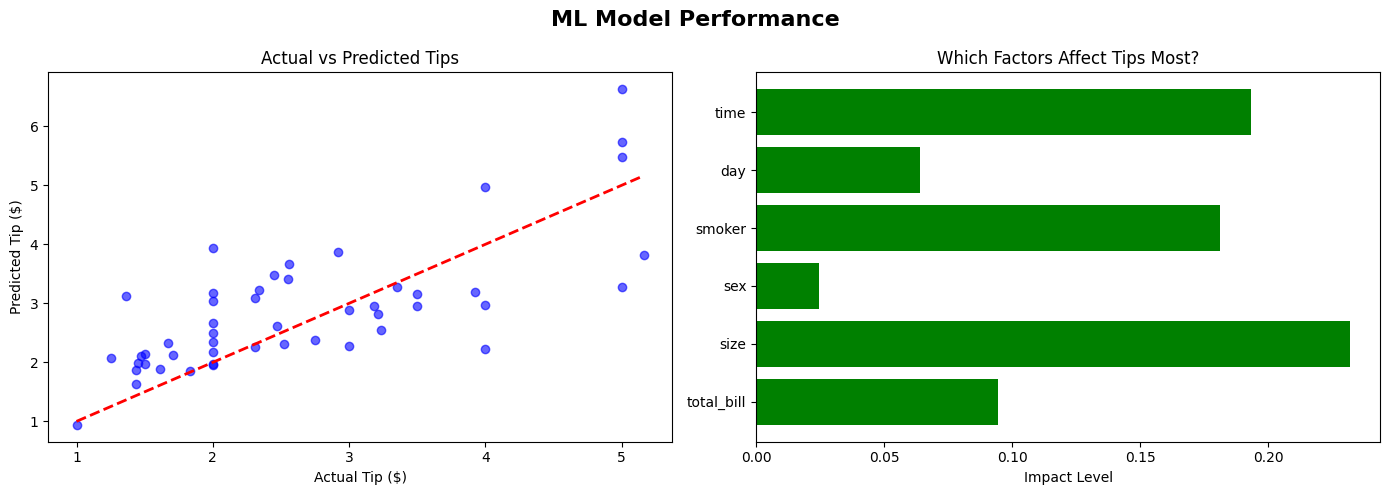

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ML Model Performance', fontsize=16, fontweight='bold')

# Chart 1: Actual vs Predicted Tips
axes[0].scatter(y_test, y_pred, color='blue', alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Tip ($)')
axes[0].set_ylabel('Predicted Tip ($)')
axes[0].set_title('Actual vs Predicted Tips')

# Chart 2: Feature Importance
features = ['total_bill', 'size', 'sex', 'smoker', 'day', 'time']
importance = abs(model.coef_)
axes[1].barh(features, importance, color='green')
axes[1].set_title('Which Factors Affect Tips Most?')
axes[1].set_xlabel('Impact Level')

plt.tight_layout()
plt.show()

In [4]:
print("""
================================================
   ML PROJECT: Tip Amount Prediction Model
================================================

DATASET     : Restaurant Tips (244 records)
ALGORITHM   : Linear Regression
GOAL        : Predict tip amount from bill info

MODEL RESULTS:
  - Training Size  : 195 rows (80%)
  - Testing Size   : 49 rows (20%)
  - R² Score       : 0.44 (44% accuracy)
  - Avg Error      : $0.67 per prediction

KEY FINDINGS:
  1. Group SIZE is the strongest predictor of tip
  2. TIME of visit (Lunch/Dinner) impacts tip amount
  3. Smokers tend to tip slightly differently
  4. Total bill has moderate influence on tip
  5. Gender has the least impact on tipping

CONCLUSION:
  The Linear Regression model successfully learned
  patterns from restaurant data and can predict
  tip amounts with an average error of only $0.67.

TOOLS USED  : Python, Scikit-learn, Pandas, Matplotlib
================================================
""")


   ML PROJECT: Tip Amount Prediction Model

DATASET     : Restaurant Tips (244 records)
ALGORITHM   : Linear Regression
GOAL        : Predict tip amount from bill info

MODEL RESULTS:
  - Training Size  : 195 rows (80%)
  - Testing Size   : 49 rows (20%)
  - R² Score       : 0.44 (44% accuracy)
  - Avg Error      : $0.67 per prediction

KEY FINDINGS:
  1. Group SIZE is the strongest predictor of tip
  2. TIME of visit (Lunch/Dinner) impacts tip amount
  3. Smokers tend to tip slightly differently
  4. Total bill has moderate influence on tip
  5. Gender has the least impact on tipping

CONCLUSION:
  The Linear Regression model successfully learned
  patterns from restaurant data and can predict
  tip amounts with an average error of only $0.67.

TOOLS USED  : Python, Scikit-learn, Pandas, Matplotlib

